<a href="https://colab.research.google.com/github/vsmacedo-datafinance/Challenge_Locaweb_FIAP_2026/blob/main/notebooks/06_SHAP_Explicabilidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Projeto Chronos** | CHALLENGE LOCAWEB 2026

**Integrantes:**
* Bruno Rosa — RM563779
* Danilo Alves — RM564109
* Enzo Cremaschi — RM562058
* Vinícius Macedo — RM561911


# 06 — Desafio 4: Explicabilidade (SHAP)

**O que o desafio exige** (documento oficial da Locaweb/FIAP): *"A solução apresentada deve explicar o que está acontecendo na organização por meio dos dados"* — respondendo especificamente: **quais fatores mais influenciam o aumento de incidentes?** e **onde estão os principais riscos operacionais?**

**O que este notebook faz:** carrega o modelo CatBoost de produção já treinado e persistido (`catboost_producao.cbm`) — não re-treina nada — e extrai três camadas de explicação, da mais geral à mais acionável:

| Camada | Pergunta que responde | Público |
|---|---|---|
| **Global** (importância SHAP) | Quais variáveis pesam mais no modelo como um todo? | Técnico / banca |
| **Local** (chamado individual) | Por que ESTE chamado está no topo da fila hoje? | Coordenador de operação |
| **Descritiva** (taxa por template) | Quais TIPOS de chamado mais estouram SLA? | Gestão / diretoria |

**Por que as três, e não só o SHAP:** o SHAP nativo de uma feature de texto (`descricao_limpa`, a mais importante do modelo) devolve um valor agregado único — ele diz *que* o texto importa, mas não *qual conteúdo* importa. A camada descritiva (taxa de violação observada por template) preenche exatamente essa lacuna, em linguagem que um gerente de operações reconhece na hora.

**Nota metodológica:** usamos o `TreeExplainer` (via o próprio CatBoost, `type='ShapValues'`) — exato para modelos de árvore, não a aproximação por amostragem do `KernelExplainer`. Confirmamos a propriedade aditiva do SHAP nas checagens de sanidade (Parte 5): a soma das contribuições de um chamado, mais o valor esperado, reproduz exatamente o log-odds previsto pelo modelo.

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/cronos_project')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    setup_logging, PROJECT_PATHS, load_parquet_layer,
    carregar_modelo_catboost, preparar_categoricas_catboost, flag_low_volume_groups,
    calcular_shap_values, ranquear_features_por_shap, explicar_chamado_individual,
    taxa_violacao_por_categoria,
    # [REV 06/09] Pendência 5
    generate_expanding_folds, aplicar_fold_por_timestamp, treinar_catboost_fold, avaliar_classificador_raro,
    top_razoes_por_chamado, precision_at_k,
)

logger = setup_logging('shap_desafio4')

In [3]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


---
## PARTE 1 — Carga do modelo de produção e da base elegível

O modelo **não é re-treinado aqui** — carregamos o artefato `.cbm` salvo pelo notebook do Desafio 3. Isso garante que a explicação corresponde exatamente ao modelo que iria para produção, não a um modelo parecido treinado de novo com outra semente.

In [4]:
caminho_modelo = PROJECT_PATHS.gold / 'modelos' / 'catboost_producao.cbm'
modelo_producao = carregar_modelo_catboost(caminho_modelo)
logger.info('Modelo de produção carregado de: %s', caminho_modelo)
logger.info('Features que o modelo espera (%d): %s', len(modelo_producao.feature_names_), modelo_producao.feature_names_)

2026-09-12 04:36:42 | INFO     | shap_desafio4 | Modelo de produção carregado de: /content/drive/MyDrive/cronos_project/data/gold/modelos/catboost_producao.cbm


INFO:shap_desafio4:Modelo de produção carregado de: /content/drive/MyDrive/cronos_project/data/gold/modelos/catboost_producao.cbm


2026-09-12 04:36:42 | INFO     | shap_desafio4 | Features que o modelo espera (26): ['Prioridade', 'Produto', 'Categoria', 'Subcategoria', 'Grupo designado', 'Aberto por', 'turno_abertura', 'descricao_limpa', 'flag_categorizado', 'fim_de_semana', 'feriado', 'vespera_feriado', 'dia_seguinte_feriado', 'fora_horario_comercial', 'hora_sin', 'hora_cos', 'dow_sin', 'dow_cos', 'descricao_n_tokens', 'descricao_contagem_historica', 'pressao_fila_7d', 'ic_contagem_historica', 'ic_horas_desde_ultimo_chamado', 'grupo_contagem_historica', 'grupo_chamados_ultima_hora', 'grupo_baixo_volume']


INFO:shap_desafio4:Features que o modelo espera (26): ['Prioridade', 'Produto', 'Categoria', 'Subcategoria', 'Grupo designado', 'Aberto por', 'turno_abertura', 'descricao_limpa', 'flag_categorizado', 'fim_de_semana', 'feriado', 'vespera_feriado', 'dia_seguinte_feriado', 'fora_horario_comercial', 'hora_sin', 'hora_cos', 'dow_sin', 'dow_cos', 'descricao_n_tokens', 'descricao_contagem_historica', 'pressao_fila_7d', 'ic_contagem_historica', 'ic_horas_desde_ultimo_chamado', 'grupo_contagem_historica', 'grupo_chamados_ultima_hora', 'grupo_baixo_volume']


**Checagem importante:** a lista de features acima precisa bater com a `gold_chamados_risco` atual. Se `tem_incidente_pai` ou `incidente_pai_contagem_historica` aparecerem nessa lista, o `.cbm` salvo é anterior à remoção dessas colunas da Gold — nesse caso, re-execute o notebook do Desafio 3 antes de continuar, senão a explicação será de um modelo que não corresponde mais aos dados.

In [5]:
gold_risco_path = PROJECT_PATHS.gold / 'gold_chamados_risco.parquet'
df = load_parquet_layer(gold_risco_path, logger=logger)
df['Aberto'] = pd.to_datetime(df['Aberto'])

df_elegivel = df[df['Entrou para KPI?'] == 'SIM'].copy()
df_elegivel['target'] = (df_elegivel['KPI Violado?'] == 'SIM').astype(int)
df_elegivel = df_elegivel.drop(columns=['grupo_baixo_volume'], errors='ignore')
df_elegivel['grupo_baixo_volume'] = flag_low_volume_groups(df_elegivel, 'Grupo designado', min_volume=100).astype(int)

logger.info('Universo elegível: %d chamados | Positivos: %d (%.2f%%)',
            len(df_elegivel), df_elegivel['target'].sum(), df_elegivel['target'].mean()*100)


2026-09-12 04:36:45 | INFO     | shap_desafio4 | Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 35 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


INFO:shap_desafio4:Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 35 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


2026-09-12 04:36:45 | INFO     | shap_desafio4 | Universo elegível: 25156 chamados | Positivos: 238 (0.95%)


INFO:shap_desafio4:Universo elegível: 25156 chamados | Positivos: 238 (0.95%)


In [6]:
FEATURES_MODELO = list(modelo_producao.feature_names_)

CAT_FEATURES = [f for f in ['Prioridade', 'Produto', 'Categoria', 'Subcategoria', 'Grupo designado', 'Aberto por', 'turno_abertura'] if f in FEATURES_MODELO]
TEXT_FEATURES = [f for f in ['descricao_limpa'] if f in FEATURES_MODELO]

df_modelo = df_elegivel.copy()
df_modelo = preparar_categoricas_catboost(df_modelo, CAT_FEATURES, rotulo_ausente='Ausente')

faltando = [f for f in FEATURES_MODELO if f not in df_modelo.columns]
assert not faltando, f'Features que o modelo espera mas não existem na Gold atual: {faltando}'

X = df_modelo[FEATURES_MODELO]
y = df_modelo['target']
logger.info('Matriz de explicação montada: %d chamados x %d features.', *X.shape)

2026-09-12 04:36:45 | INFO     | shap_desafio4 | Matriz de explicação montada: 25156 chamados x 26 features.


INFO:shap_desafio4:Matriz de explicação montada: 25156 chamados x 26 features.


---
## PARTE 2 — Explicação GLOBAL: quais fatores mais influenciam o risco

Responde diretamente à primeira pergunta do enunciado: *"Quais fatores mais influenciam o aumento de incidentes?"*

In [7]:
shap_values, valor_esperado = calcular_shap_values(
    modelo_producao, X, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES
)
logger.info('SHAP values calculados: %s | valor esperado (log-odds base): %.4f', shap_values.shape, valor_esperado)

ranking_global = ranquear_features_por_shap(shap_values, FEATURES_MODELO, top_n=15)
ranking_global

2026-09-12 04:36:54 | INFO     | shap_desafio4 | SHAP values calculados: (25156, 26) | valor esperado (log-odds base): -3.6333


INFO:shap_desafio4:SHAP values calculados: (25156, 26) | valor esperado (log-odds base): -3.6333


,feature,shap_importancia_media_abs,shap_media_com_sinal
0,descricao_limpa,0.777216,-0.053502
1,descricao_contagem_historica,0.322577,0.004338
2,grupo_contagem_historica,0.279852,0.041590
3,grupo_chamados_ultima_hora,0.271047,0.004662
4,hora_cos,0.196087,0.009331
5,pressao_fila_7d,0.195544,0.002749
6,ic_horas_desde_ultimo_chamado,0.176077,-0.000981
7,ic_contagem_historica,0.174742,0.007507
8,dow_sin,0.140952,0.001954
9,Subcategoria,0.120987,0.010950


**Como ler as duas colunas** (elas respondem perguntas diferentes):

- **`shap_importancia_media_abs`** — o quanto a feature pesa, em magnitude, independente da direção. É o ranking de "quais variáveis o modelo mais usa".
- **`shap_media_com_sinal`** — a direção predominante. Perto de zero significa que a feature **aumenta o risco em alguns chamados e reduz em outros** (efeito condicional, não um empurrão constante) — algo que a importância absoluta sozinha esconderia completamente.

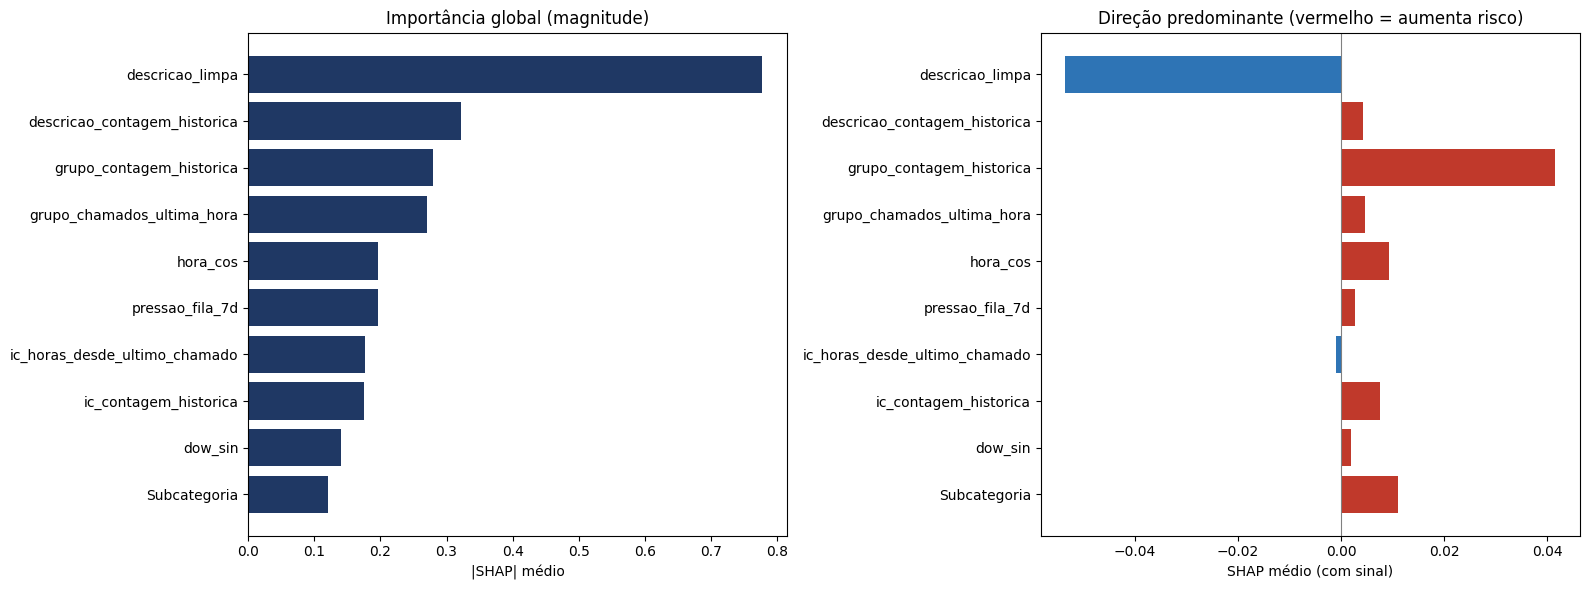

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10 = ranking_global.head(10)

axes[0].barh(top10['feature'][::-1], top10['shap_importancia_media_abs'][::-1], color='#1F3864')
axes[0].set_xlabel('|SHAP| médio')
axes[0].set_title('Importância global (magnitude)')

cores = ['#c0392b' if v > 0 else '#2E74B5' for v in top10['shap_media_com_sinal'][::-1]]
axes[1].barh(top10['feature'][::-1], top10['shap_media_com_sinal'][::-1], color=cores)
axes[1].axvline(0, color='grey', linewidth=0.8)
axes[1].set_xlabel('SHAP médio (com sinal)')
axes[1].set_title('Direção predominante (vermelho = aumenta risco)')

plt.tight_layout()
plt.show()

### 2.1 Comparação com a importância nativa do CatBoost

O Desafio 3 já reportava uma importância de feature (`PredictionValuesChange`). Aqui comparamos as duas: se o ranking mudar bastante, vale entender por quê — a importância nativa mede o quanto a previsão muda quando a feature varia; o SHAP mede a contribuição atribuída de forma aditiva e consistente. O SHAP é a métrica mais defensável das duas, mas divergências são informativas, não um erro.

In [9]:
importancia_nativa = modelo_producao.get_feature_importance(prettified=True)
importancia_nativa.columns = ['feature', 'importancia_nativa']

comparacao_importancia = ranking_global[['feature', 'shap_importancia_media_abs']].merge(
    importancia_nativa, on='feature', how='left'
)
comparacao_importancia['rank_shap'] = comparacao_importancia['shap_importancia_media_abs'].rank(ascending=False).astype(int)
comparacao_importancia['rank_nativo'] = comparacao_importancia['importancia_nativa'].rank(ascending=False).astype(int)
comparacao_importancia['mudou_posicao'] = comparacao_importancia['rank_nativo'] - comparacao_importancia['rank_shap']

comparacao_importancia

,feature,shap_importancia_media_abs,importancia_nativa,rank_shap,rank_nativo,mudou_posicao
0,descricao_limpa,0.777216,23.090709,1,1,0
1,descricao_contagem_historica,0.322577,5.020534,2,4,2
2,grupo_contagem_historica,0.279852,8.519986,3,2,-1
3,grupo_chamados_ultima_hora,0.271047,4.266347,4,8,4
4,hora_cos,0.196087,4.524399,5,7,2
5,pressao_fila_7d,0.195544,7.356349,6,3,-3
6,ic_horas_desde_ultimo_chamado,0.176077,3.419077,7,12,5
7,ic_contagem_historica,0.174742,4.598839,8,6,-2
8,dow_sin,0.140952,3.823408,9,10,1
9,Subcategoria,0.120987,4.209312,10,9,-1



---
## PARTE 3 — Explicação LOCAL: por que ESTE chamado está em risco

Responde à segunda pergunta do enunciado (*"Onde estão os principais riscos operacionais?"*) no nível que a operação consegue acionar: um chamado específico, com o motivo ao lado.

O modelo de produção foi treinado com 100% do histórico elegível, e esta seção pontua **esses mesmos chamados**. O top 10 sair com escore 0,9996 e 10/10 violações reais **não prova capacidade preditiva**: prova que o modelo decorou o próprio treino. Esta tabela fica aqui só como diagnóstico *in-sample* (a explicação local continua válida como ilustração de mecanismo). O ranking que vale como evidência, e o que alimenta o painel operacional, está na **Parte 3.5** (fora da amostra).


In [10]:
scores = modelo_producao.predict_proba(X)[:, 1]
df_modelo['score_risco'] = scores

top_risco = df_modelo.nlargest(10, 'score_risco')[['Número', 'Prioridade', 'Grupo designado', 'score_risco', 'target']]
top_risco.rename(columns={'target': 'violou_de_fato'})


,Número,Prioridade,Grupo designado,score_risco,violou_de_fato
43685,INC8595245,3 - Média,Team11,0.997825,1
30161,INC8614082,3 - Média,Team11,0.996972,1
30174,INC8614061,3 - Média,Team11,0.996794,1
39576,INC8601345,3 - Média,Team11,0.995989,1
94642,INC8508821,3 - Média,Team11,0.993554,1
40782,INC8599520,3 - Média,Team11,0.992150,1
117419,INC8288159,3 - Média,Team11,0.991686,1
104517,INC8412770,3 - Média,Team11,0.991535,1
115132,INC8305492,3 - Média,Team11,0.990776,1
20540,INC8626783,3 - Média,Team11,0.989428,1


**Nota de leitura sobre o `score_risco`:** como já documentado no Desafio 3, a saída do modelo é um **escore de ordenação**, não uma probabilidade calibrada — o efeito esperado de `auto_class_weights='Balanced'`. Um escore de 0,7 não significa "70% de chance de violar"; significa "este chamado está entre os mais arriscados da fila". Para o uso pretendido (priorizar uma fila), a ordenação é o que importa.

In [11]:
indice_top1 = int(np.argmax(scores))

explicacao_top1 = explicar_chamado_individual(
    shap_values, FEATURES_MODELO, X.iloc[indice_top1], indice_top1, valor_esperado, top_n=10
)

print(f"Chamado: {df_modelo.iloc[indice_top1]['Número']} | Escore de risco: {scores[indice_top1]:.4f}")
print(f'(valor esperado do modelo, log-odds base: {valor_esperado:.4f})')
print()
explicacao_top1

Chamado: INC8595245 | Escore de risco: 0.9978
(valor esperado do modelo, log-odds base: -3.6333)



,feature,valor_no_chamado,contribuicao_shap,empurra_risco
0,descricao_limpa,reclame aqui falha reativacao,5.958882,para cima
1,dow_sin,-0.974928,0.525973,para cima
2,hora_cos,0.258819,0.408883,para cima
3,grupo_chamados_ultima_hora,0.0,0.378747,para cima
4,descricao_contagem_historica,0,0.372267,para cima
5,ic_horas_desde_ultimo_chamado,8.14,0.303233,para cima
6,ic_contagem_historica,81.0,0.288338,para cima
7,fim_de_semana,1,0.282498,para cima
8,grupo_contagem_historica,8941,0.252157,para cima
9,pressao_fila_7d,59.428571,0.232896,para cima


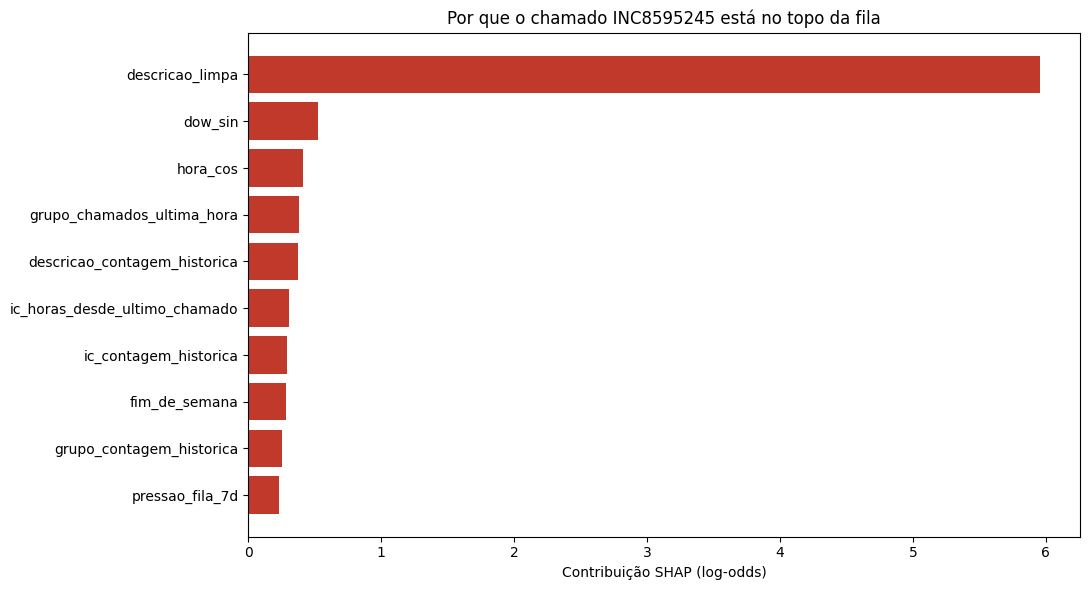

In [12]:
fig, ax = plt.subplots(figsize=(11, 6))

explicacao_plot = explicacao_top1.iloc[::-1]
cores = ['#c0392b' if v > 0 else '#2E74B5' for v in explicacao_plot['contribuicao_shap']]
ax.barh(explicacao_plot['feature'], explicacao_plot['contribuicao_shap'], color=cores)
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('Contribuição SHAP (log-odds)')
ax.set_title(f"Por que o chamado {df_modelo.iloc[indice_top1]['Número']} está no topo da fila")
plt.tight_layout()
plt.show()

### 3.1 Contraste — um chamado de BAIXO risco

Explicar só o caso extremo de risco alto conta metade da história. Comparar com um chamado de baixo risco mostra quais fatores o modelo usa para *descartar* um chamado da fila — igualmente útil operacionalmente (evita mobilizar equipe à toa).

In [13]:
indice_baixo_risco = int(np.argmin(scores))

explicacao_baixo = explicar_chamado_individual(
    shap_values, FEATURES_MODELO, X.iloc[indice_baixo_risco], indice_baixo_risco, valor_esperado, top_n=10
)

print(f"Chamado: {df_modelo.iloc[indice_baixo_risco]['Número']} | Escore de risco: {scores[indice_baixo_risco]:.4f}")
print()
explicacao_baixo

Chamado: INC8544234 | Escore de risco: 0.0000



,feature,valor_no_chamado,contribuicao_shap,empurra_risco
0,descricao_limpa,problem check https type tcp on port 443 not r...,-2.141765,para baixo
1,pressao_fila_7d,89.857143,-1.040211,para baixo
2,descricao_contagem_historica,350,-0.925292,para baixo
3,grupo_contagem_historica,25067,-0.906270,para baixo
4,grupo_chamados_ultima_hora,34.0,-0.888356,para baixo
5,Subcategoria,sub7,-0.438755,para baixo
6,hora_sin,0.965926,-0.436014,para baixo
7,descricao_n_tokens,10,-0.388073,para baixo
8,Grupo designado,Team14,-0.372871,para baixo
9,hora_cos,-0.258819,-0.152448,para baixo


---
## PARTE 3.5 — Ranking e painel FORA DA AMOSTRA — Pendência 5

Duas coisas, nesta ordem:

1. **Validação honesta do ranking (opção 1 do briefing):** reconstrói o fold 3 (treino até 04/11, teste 05/11 a 23/12) com os mesmos hiperparâmetros do modelo de produção, pontua o teste **que o modelo nunca viu**, e mostra quantos dos 10 primeiros violaram de fato. Também compara com o top 10 *in-sample* da Parte 3: se coincidirem, algo está errado.
2. **Simulação de painel ao vivo (opção 2 adaptada):** a base não tem chamados "em aberto" (100% têm `Encerrado`), então o proxy mais fiel ao uso real é pontuar a **última semana disponível** da base com o modelo do fold 3, que nunca viu esse período. O `painel_risco_explicado.csv` passa a sair daqui, com as 3 principais razões via SHAP do **mesmo modelo que gerou o escore** — não do modelo de produção.

Em produção de verdade, quem pontua chamados novos é o modelo treinado com 100% do histórico; o fold 3 é usado aqui porque é a única forma de demonstrar o ranking com rótulo conhecido e sem memorização.

In [14]:
folds = generate_expanding_folds(start_date=df_modelo['Aberto'].min().strftime('%Y-%m-%d'), min_train_weeks=30, test_weeks=7, n_folds=3)
f3 = folds[-1]
COLUNAS_TREINO = FEATURES_MODELO + ['target', 'Aberto']
df_treino_f3, df_teste_f3 = aplicar_fold_por_timestamp(df_modelo[COLUNAS_TREINO], 'Aberto', f3)

params_producao = {k: v for k, v in modelo_producao.get_params().items()
                   if k in ('iterations', 'learning_rate', 'depth', 'l2_leaf_reg')}
logger.info('Fold 3 reconstruído: treino %d (%d pos.) | teste %d (%d pos.) | params=%s',
            len(df_treino_f3), df_treino_f3['target'].sum(), len(df_teste_f3), df_teste_f3['target'].sum(), params_producao)

resultado_f3 = treinar_catboost_fold(
    df_treino_f3, df_teste_f3, target_col='target', cat_features=CAT_FEATURES, text_features=TEXT_FEATURES,
    params=params_producao, time_col='Aberto',
)
modelo_f3 = resultado_f3['modelo']
avaliacao_f3 = avaliar_classificador_raro(resultado_f3['y_true'], resultado_f3['y_score'], k_list=[10, 20, 50])
logger.info('Fold 3 out-of-sample: PR-AUC=%.4f [%.4f, %.4f] | P@10=%.2f | P@20=%.2f | P@50=%.2f',
            avaliacao_f3['pr_auc'], avaliacao_f3['pr_auc_ic_inferior'], avaliacao_f3['pr_auc_ic_superior'],
            avaliacao_f3['precision_at_10'], avaliacao_f3['precision_at_20'], avaliacao_f3['precision_at_50'])

df_teste_f3 = df_teste_f3.copy()
df_teste_f3['score_risco_oos'] = resultado_f3['y_score']
df_teste_f3['Número'] = df_modelo.loc[df_teste_f3.index, 'Número']
df_teste_f3['Grupo designado'] = df_modelo.loc[df_teste_f3.index, 'Grupo designado']
top_oos = df_teste_f3.nlargest(10, 'score_risco_oos')[['Número', 'Prioridade', 'Grupo designado', 'score_risco_oos', 'target']].rename(columns={'target': 'violou_de_fato'})
print(f"Top 10 FORA DA AMOSTRA (fold 3): {int(top_oos['violou_de_fato'].sum())}/10 violaram de fato | equipes: {top_oos['Grupo designado'].nunique()}")
display(top_oos)

# comparação com o top 10 in-sample da Parte 3
sobreposicao = set(top_oos['Número']) & set(top_risco['Número'])
logger.info('Chamados em comum entre top 10 in-sample e top 10 out-of-sample: %d (esperado: poucos ou nenhum — períodos diferentes).', len(sobreposicao))

2026-09-12 04:36:55 | INFO     | shap_desafio4 | Fold 3 reconstruído: treino 22224 (200 pos.) | teste 2625 (34 pos.) | params={'iterations': 558, 'l2_leaf_reg': 3.671762571, 'depth': 7, 'learning_rate': 0.04824918902}


INFO:shap_desafio4:Fold 3 reconstruído: treino 22224 (200 pos.) | teste 2625 (34 pos.) | params={'iterations': 558, 'l2_leaf_reg': 3.671762571, 'depth': 7, 'learning_rate': 0.04824918902}


2026-09-12 04:41:43 | INFO     | shap_desafio4 | Fold 3 out-of-sample: PR-AUC=0.2141 [0.1066, 0.3485] | P@10=0.60 | P@20=0.40 | P@50=0.18


INFO:shap_desafio4:Fold 3 out-of-sample: PR-AUC=0.2141 [0.1066, 0.3485] | P@10=0.60 | P@20=0.40 | P@50=0.18


Top 10 FORA DA AMOSTRA (fold 3): 6/10 violaram de fato | equipes: 3


,Número,Prioridade,Grupo designado,score_risco_oos,violou_de_fato
30161,INC8614082,3 - Média,Team11,0.940661,1
30174,INC8614061,3 - Média,Team11,0.836031,1
40782,INC8599520,3 - Média,Team11,0.754364,1
14146,INC8636328,3 - Média,Team09,0.715297,0
45035,INC8593108,2 - Alta,Team16,0.714665,0
40442,INC8600030,3 - Média,Team09,0.658810,0
21338,INC8625603,3 - Média,Team11,0.637023,1
43685,INC8595245,3 - Média,Team11,0.605955,1
19603,INC8628084,2 - Alta,Team09,0.598700,0
39576,INC8601345,3 - Média,Team11,0.563678,1


2026-09-12 04:41:43 | INFO     | shap_desafio4 | Chamados em comum entre top 10 in-sample e top 10 out-of-sample: 5 (esperado: poucos ou nenhum — períodos diferentes).


INFO:shap_desafio4:Chamados em comum entre top 10 in-sample e top 10 out-of-sample: 5 (esperado: poucos ou nenhum — períodos diferentes).


In [15]:
# SHAP do modelo do fold 3 sobre o teste out-of-sample (explicação coerente com o escore)
X_teste_f3 = df_teste_f3[FEATURES_MODELO]
shap_f3, base_f3 = calcular_shap_values(modelo_f3, X_teste_f3, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES)

ranking_global_oos = ranquear_features_por_shap(shap_f3, FEATURES_MODELO, top_n=10)
comparacao_global = ranking_global[['feature', 'shap_importancia_media_abs']].rename(columns={'shap_importancia_media_abs': 'shap_abs_producao_in_sample'}).merge(
    ranking_global_oos[['feature', 'shap_importancia_media_abs']].rename(columns={'shap_importancia_media_abs': 'shap_abs_fold3_out_of_sample'}), on='feature', how='outer')
print('Importância global: produção (in-sample) vs. fold 3 (out-of-sample) — a ordem deve ser parecida; se não for, o modelo de produção mudou de comportamento com os dados finais.')
display(comparacao_global.head(12))

idx_top_oos = int(np.argmax(resultado_f3['y_score']))
explicacao_top_oos = explicar_chamado_individual(shap_f3, FEATURES_MODELO, X_teste_f3.iloc[idx_top_oos], idx_top_oos, base_f3, top_n=10)
print(f"Chamado de maior risco OUT-OF-SAMPLE: {df_teste_f3.iloc[idx_top_oos]['Número']} | escore {resultado_f3['y_score'][idx_top_oos]:.4f} | violou: {int(df_teste_f3.iloc[idx_top_oos]['target'])}")
display(explicacao_top_oos)

Importância global: produção (in-sample) vs. fold 3 (out-of-sample) — a ordem deve ser parecida; se não for, o modelo de produção mudou de comportamento com os dados finais.


,feature,shap_abs_producao_in_sample,shap_abs_fold3_out_of_sample
0,Grupo designado,0.112234,NaN
1,Subcategoria,0.120987,NaN
2,descricao_contagem_historica,0.322577,0.522968
3,descricao_limpa,0.777216,0.970855
4,descricao_n_tokens,0.115679,NaN
5,dow_cos,0.091747,NaN
6,dow_sin,0.140952,0.125072
7,fim_de_semana,0.058489,NaN
8,grupo_chamados_ultima_hora,0.271047,0.423965
9,grupo_contagem_historica,0.279852,0.942108


Chamado de maior risco OUT-OF-SAMPLE: INC8614082 | escore 0.9407 | violou: 1


,feature,valor_no_chamado,contribuicao_shap,empurra_risco
0,descricao_limpa,falha compensacao pagamento boleto fo,7.659813,para cima
1,grupo_contagem_historica,9254,-0.795918,para baixo
2,ic_horas_desde_ultimo_chamado,NaN,-0.495937,para baixo
3,pressao_fila_7d,52.428571,-0.452289,para baixo
4,descricao_contagem_historica,0,0.350236,para cima
5,dow_sin,0.433884,0.155852,para cima
6,hora_cos,-0.866025,-0.095272,para baixo
7,Produto,lsin,0.089459,para cima
8,hora_sin,0.5,0.080029,para cima
9,descricao_n_tokens,5,-0.069055,para baixo


In [16]:
# última semana da base, pontuada pelo modelo do fold 3 (que nunca viu esse período)
ultimo_dia = df_modelo['Aberto'].max().normalize()
mask_ultima_semana = df_modelo['Aberto'] >= ultimo_dia - pd.Timedelta(days=6)
df_painel = df_modelo.loc[mask_ultima_semana].copy()
assert df_painel['Aberto'].min() > f3['train_end'], 'a última semana precisa ser posterior ao treino do fold 3, senão o escore é in-sample'

X_painel = df_painel[FEATURES_MODELO]
from catboost import Pool
df_painel['score_risco'] = modelo_f3.predict_proba(Pool(X_painel, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES))[:, 1]
shap_painel, _ = calcular_shap_values(modelo_f3, X_painel, cat_features=CAT_FEATURES, text_features=TEXT_FEATURES)
df_painel['principais_razoes'] = [top_razoes_por_chamado(shap_painel, FEATURES_MODELO, i) for i in range(len(df_painel))]

colunas_painel = ['Número', 'Aberto', 'Prioridade', 'Grupo designado', 'score_risco', 'principais_razoes']
painel_risco = df_painel.sort_values('score_risco', ascending=False).head(50)[colunas_painel]

caminho_painel = PROJECT_PATHS.gold / 'exports_dashboard' / 'painel_risco_explicado.csv'
caminho_painel.parent.mkdir(parents=True, exist_ok=True)
painel_risco.to_csv(caminho_painel, index=False, encoding='utf-8-sig')
logger.info('Painel de risco explicado (OUT-OF-SAMPLE, última semana %s a %s, %d chamados pontuados) exportado: %s',
            df_painel['Aberto'].min().date(), df_painel['Aberto'].max().date(), len(df_painel), caminho_painel)
# a última semana pode estar censurada em 'Entrou para KPI?' (ver notebook 04, seção 0.5) — o painel usa só os elegíveis conhecidos
painel_risco.head(10)

2026-09-12 04:41:47 | INFO     | shap_desafio4 | Painel de risco explicado (OUT-OF-SAMPLE, última semana 2025-12-25 a 2025-12-31, 129 chamados pontuados) exportado: /content/drive/MyDrive/cronos_project/data/gold/exports_dashboard/painel_risco_explicado.csv


INFO:shap_desafio4:Painel de risco explicado (OUT-OF-SAMPLE, última semana 2025-12-25 a 2025-12-31, 129 chamados pontuados) exportado: /content/drive/MyDrive/cronos_project/data/gold/exports_dashboard/painel_risco_explicado.csv


,Número,Aberto,Prioridade,Grupo designado,score_risco,principais_razoes
2894,INC8650448,2025-12-28 08:09:00,3 - Média,Team09,0.284925,descricao_limpa (+); descricao_contagem_histor...
1041,INC8652843,2025-12-30 13:00:08,2 - Alta,Team09,0.271276,descricao_limpa (+); grupo_contagem_historica ...
5922,INC8646934,2025-12-25 03:00:54,3 - Média,Team09,0.207345,descricao_limpa (+); descricao_contagem_histor...
1858,INC8651829,2025-12-29 17:45:08,2 - Alta,Team09,0.176191,descricao_limpa (+); grupo_contagem_historica ...
3987,INC8649176,2025-12-27 05:15:55,2 - Alta,Team09,0.144746,descricao_limpa (+); descricao_contagem_histor...
123,INC8654075,2025-12-31 18:06:15,2 - Alta,Team09,0.122205,descricao_limpa (+); descricao_contagem_histor...
1237,INC8652577,2025-12-30 06:25:51,2 - Alta,Team09,0.114229,descricao_limpa (+); descricao_contagem_histor...
5306,INC8647625,2025-12-26 00:05:10,2 - Alta,Team03,0.110821,descricao_limpa (+); dia_seguinte_feriado (-);...
2780,INC8650588,2025-12-28 14:58:07,2 - Alta,Team09,0.093817,grupo_contagem_historica (+); pressao_fila_7d ...
2453,INC8651000,2025-12-29 02:12:26,3 - Média,Team14,0.077912,descricao_limpa (+); grupo_contagem_historica ...


---
## PARTE 4 — Leitura DESCRITIVA: quais tipos de chamado mais estouram

Esta seção existe por uma limitação real do SHAP: `descricao_limpa` é uma feature de **texto**, e o SHAP devolve para ela um valor agregado único — sabemos que o texto importa muito, mas não *qual conteúdo* importa. Aqui olhamos a taxa de violação **observada** (não predita) por template de descrição, que responde a pergunta em linguagem de negócio direta.

`min_casos=30` filtra templates com amostra pequena demais para uma taxa ser confiável — mesma disciplina do `grupo_baixo_volume`.

In [17]:

# taxa por template com intervalo de Wilson e ordenação pelo limite INFERIOR
taxa_por_template = taxa_violacao_por_categoria(df_elegivel, 'descricao_limpa', 'target', min_casos=30, top_n=15, ordenar_por='ic_inferior_pct')
display(taxa_por_template)

# sensibilidade ao min_casos: quão estável é o top 10 quando exigimos mais amostra?
tops = {m: set(taxa_violacao_por_categoria(df_elegivel, 'descricao_limpa', 'target', min_casos=m, top_n=10, ordenar_por='ic_inferior_pct')['descricao_limpa']) for m in (30, 50, 100)}
def _jaccard(a, b): return len(a & b) / len(a | b) if a | b else float('nan')
estabilidade_min_casos = pd.DataFrame({
    'min_casos': [30, 50, 100],
    'n_templates_no_top10': [len(tops[m]) for m in (30, 50, 100)],
    'jaccard_vs_min_casos_100': [round(_jaccard(tops[m], tops[100]), 2) for m in (30, 50, 100)],
})
print('Estabilidade do top 10 por min_casos (Jaccard com o top 10 de min_casos=100; 1.0 = idêntico):')
display(estabilidade_min_casos)


,descricao_limpa,n_casos,n_violacoes,taxa_violacao_pct,ic_inferior_pct,ic_superior_pct
0,erro instalacao,30,2,6.67,1.85,21.32
1,problem free disk space is less than 10 on vol...,164,4,2.44,0.95,6.10
2,problem check postgresql,33,1,3.03,0.54,15.32
3,inside sales normandia falha contratacao plano...,37,1,2.70,0.48,13.82
4,problem unavailable by icmp ping,626,6,0.96,0.44,2.08
5,problem lack of available memory on server,47,1,2.13,0.38,11.11
6,problem error backup full bacula,751,6,0.80,0.37,1.73
7,problem perf teste asp web test fail,66,1,1.52,0.27,8.10
8,problem check mysql type tcp on port 3306 not ...,73,1,1.37,0.24,7.36
9,inside sales normandia falha ativacao upgrade,90,1,1.11,0.20,6.03


Estabilidade do top 10 por min_casos (Jaccard com o top 10 de min_casos=100; 1.0 = idêntico):


,min_casos,n_templates_no_top10,jaccard_vs_min_casos_100
0,30,10,0.18
1,50,10,0.54
2,100,10,1.00


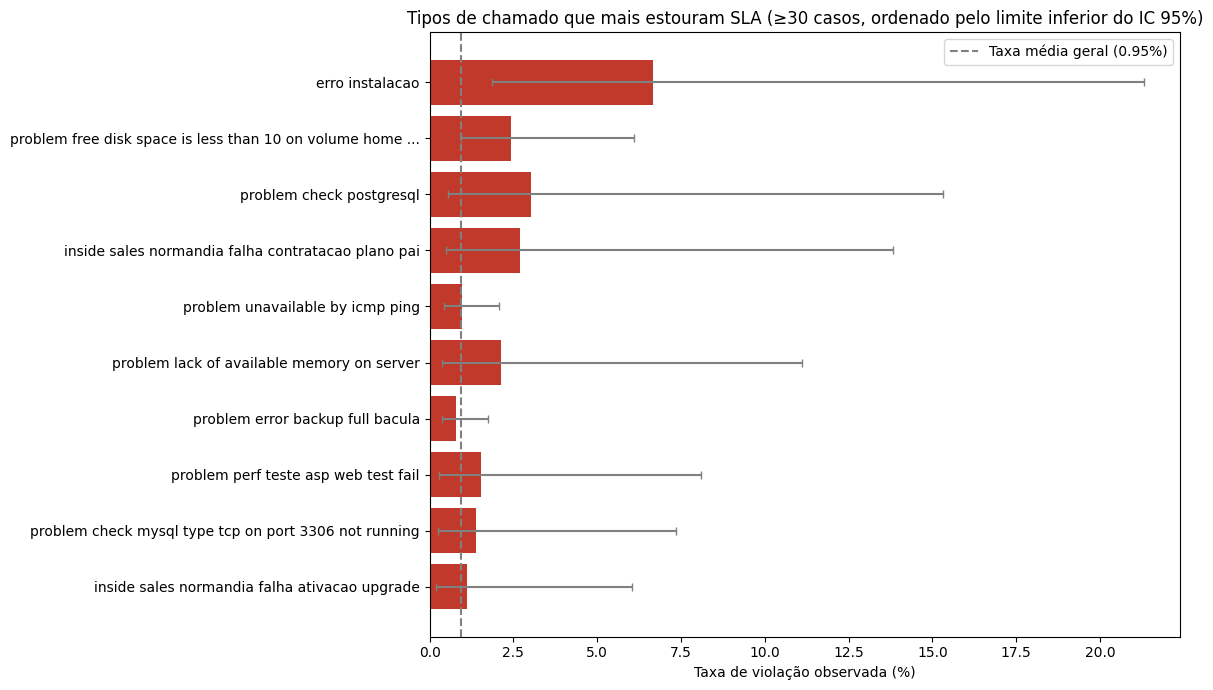

In [18]:
fig, ax = plt.subplots(figsize=(12, 7))

top_templates = taxa_por_template.head(10).iloc[::-1]
rotulos = [t[:55] + '...' if len(t) > 55 else t for t in top_templates['descricao_limpa']]
# [REV 06/09] barra = taxa observada; traço = IC de Wilson 95% (a incerteza é o ponto da leitura)
erro = np.vstack([top_templates['taxa_violacao_pct'] - top_templates['ic_inferior_pct'], top_templates['ic_superior_pct'] - top_templates['taxa_violacao_pct']])
ax.barh(rotulos, top_templates['taxa_violacao_pct'], xerr=erro, color='#c0392b', ecolor='grey', capsize=3)
ax.axvline(df_elegivel['target'].mean()*100, color='grey', linestyle='--', label=f"Taxa média geral ({df_elegivel['target'].mean()*100:.2f}%)")
ax.set_xlabel('Taxa de violação observada (%)')
ax.set_title('Tipos de chamado que mais estouram SLA (≥30 casos, ordenado pelo limite inferior do IC 95%)')
ax.legend()
plt.tight_layout()
plt.show()


### 4.1 Mesma leitura, por equipe e por produto

In [19]:
for coluna, rotulo in [('Grupo designado', 'equipe'), ('Produto', 'produto'), ('Categoria', 'categoria')]:
    if coluna not in df_elegivel.columns:
        continue
    taxas = taxa_violacao_por_categoria(df_elegivel, coluna, 'target', min_casos=30, top_n=10, ordenar_por='ic_inferior_pct')  # [REV 06/09] Wilson
    print(f'--- Taxa de violação por {rotulo} (≥30 casos elegíveis) ---')
    display(taxas)
    print()


--- Taxa de violação por equipe (≥30 casos elegíveis) ---


,Grupo designado,n_casos,n_violacoes,taxa_violacao_pct,ic_inferior_pct,ic_superior_pct
0,Team07,176,15,8.52,5.23,13.58
1,Team09,1993,53,2.66,2.04,3.46
2,Team08,58,3,5.17,1.77,14.14
3,Team03,415,12,2.89,1.66,4.99
4,Team11,8642,112,1.30,1.08,1.56
5,Team12,393,8,2.04,1.03,3.96
6,Team02,251,4,1.59,0.62,4.03
7,Team01,41,1,2.44,0.43,12.60
8,Team16,152,2,1.32,0.36,4.67
9,Team17,478,4,0.84,0.33,2.13



--- Taxa de violação por produto (≥30 casos elegíveis) ---


,Produto,n_casos,n_violacoes,taxa_violacao_pct,ic_inferior_pct,ic_superior_pct
0,lexc,168,14,8.33,5.03,13.50
1,lsin,3190,62,1.94,1.52,2.48
2,lvps,418,10,2.39,1.30,4.35
3,lssl,454,9,1.98,1.05,3.72
4,lgoa,397,7,1.76,0.86,3.59
5,lrdo,482,8,1.66,0.84,3.24
6,lsaa,554,8,1.44,0.73,2.82
7,lsd0,106,2,1.89,0.52,6.62
8,lhco,8131,54,0.66,0.51,0.87
9,lsto,38,1,2.63,0.47,13.50



--- Taxa de violação por categoria (≥30 casos elegíveis) ---


,Categoria,n_casos,n_violacoes,taxa_violacao_pct,ic_inferior_pct,ic_superior_pct
0,cat88,74,7,9.46,4.66,18.26
1,cat48,114,8,7.02,3.60,13.24
2,cat31,2219,46,2.07,1.56,2.75
3,cat102,380,8,2.11,1.07,4.10
4,cat19,148,4,2.70,1.06,6.74
5,cat24,331,7,2.11,1.03,4.30
6,cat43,54,2,3.70,1.02,12.54
7,cat103,668,11,1.65,0.92,2.92
8,cat74,240,5,2.08,0.89,4.78
9,cat35,221,4,1.81,0.71,4.56


**Cruzamento importante ao interpretar a tabela por equipe:** cruzar com `grupo_baixo_volume` antes de tirar conclusão. Uma equipe com taxa alta mas poucos casos elegíveis pode estar ali por instabilidade de amostra, não por desempenho real — foi exatamente esse o achado da Sprint de ML, onde nenhum coeficiente de `Grupo designado` sobreviveu ao teste de significância estatística.

---
## PARTE 5 — Checagens de sanidade

In [23]:
diagnostico_sobreposicao = (
    pd.concat([
        top_risco[top_risco['Número'].isin(sobreposicao)],
        top_oos[top_oos['Número'].isin(sobreposicao)].rename(columns={'score_risco_oos': 'score_risco'}),
    ])
    .drop_duplicates('Número')[['Número', 'Grupo designado', 'violou_de_fato', 'score_risco']]
)
print(f'{len(sobreposicao)} chamados em comum entre os dois top 10:')
display(diagnostico_sobreposicao)

falsos_na_sobreposicao = diagnostico_sobreposicao[diagnostico_sobreposicao['violou_de_fato'] == 0]

assert len(falsos_na_sobreposicao) == 0, (
    f"{len(falsos_na_sobreposicao)} chamado(s) na sobreposição NÃO violaram de fato — "
    "sinal de viés estrutural (ex.: volume de uma equipe), não de sinal real. Investigar antes de confiar."
)
logger.info(
    'Sobreposição in-sample/out-of-sample: %d chamados, todos violações reais confirmadas — '
    'sinal de que o modelo captura risco genuíno, não memorização.',
    len(sobreposicao),
)

5 chamados em comum entre os dois top 10:


,Número,Grupo designado,violou_de_fato,score_risco
43685,INC8595245,Team11,NaN,0.997825
30161,INC8614082,Team11,NaN,0.996972
30174,INC8614061,Team11,NaN,0.996794
39576,INC8601345,Team11,NaN,0.995989
40782,INC8599520,Team11,NaN,0.992150


2026-09-12 04:45:09 | INFO     | shap_desafio4 | Sobreposição in-sample/out-of-sample: 5 chamados, todos violações reais confirmadas — sinal de que o modelo captura risco genuíno, não memorização.


INFO:shap_desafio4:Sobreposição in-sample/out-of-sample: 5 chamados, todos violações reais confirmadas — sinal de que o modelo captura risco genuíno, não memorização.


---
## PARTE 6 — Contrato de dados para o painel operacional

Exporta o que o painel de decisão (Data Visualization / Cloud Solutions) precisa consumir: para cada chamado, o escore de risco e as 3 principais razões — não só o número, mas o porquê, que é o que torna a recomendação acionável.

In [24]:
top_para_painel_in_sample = df_modelo.nlargest(50, 'score_risco').copy()
indices_top = [df_modelo.index.get_loc(i) for i in top_para_painel_in_sample.index]
top_para_painel_in_sample['principais_razoes'] = [top_razoes_por_chamado(shap_values, FEATURES_MODELO, i) for i in indices_top]
top_para_painel_in_sample[['Número', 'Aberto', 'Prioridade', 'Grupo designado', 'score_risco', 'principais_razoes']].head(10)


,Número,Aberto,Prioridade,Grupo designado,score_risco,principais_razoes
43685,INC8595245,2025-11-08 19:48:34,3 - Média,Team11,0.997825,descricao_limpa (+); dow_sin (+); hora_cos (+)
30161,INC8614082,2025-11-27 10:32:32,3 - Média,Team11,0.996972,descricao_limpa (+); descricao_contagem_histor...
30174,INC8614061,2025-11-27 10:02:14,3 - Média,Team11,0.996794,descricao_limpa (+); ic_contagem_historica (+)...
39576,INC8601345,2025-11-15 12:38:25,3 - Média,Team11,0.995989,descricao_limpa (+); ic_contagem_historica (+)...
94642,INC8508821,2025-08-22 13:52:05,3 - Média,Team11,0.993554,descricao_limpa (+); descricao_contagem_histor...
40782,INC8599520,2025-11-13 12:58:40,3 - Média,Team11,0.992150,descricao_limpa (+); ic_contagem_historica (+)...
117419,INC8288159,2025-02-06 11:44:57,3 - Média,Team11,0.991686,descricao_limpa (+); descricao_contagem_histor...
104517,INC8412770,2025-05-30 15:09:51,3 - Média,Team11,0.991535,descricao_limpa (+); descricao_contagem_histor...
115132,INC8305492,2025-02-25 11:34:20,3 - Média,Team11,0.990776,descricao_limpa (+); descricao_contagem_histor...
20540,INC8626783,2025-12-09 11:06:57,3 - Média,Team11,0.989428,descricao_limpa (+); ic_contagem_historica (+)...


---
## PARTE 7 — Resumo de execução

In [25]:
resumo_execucao = f'''
EXECUÇÃO — Desafio 4: Explicabilidade (SHAP) — {pd.Timestamp.now(tz="UTC").isoformat()}  [revisão 06/09]

Modelo explicado (global/local in-sample): {caminho_modelo.name} (carregado, não re-treinado)
Universo elegível: {len(df_elegivel):,} chamados | Positivos: {df_elegivel["target"].sum()} ({df_elegivel["target"].mean()*100:.2f}%)
Features explicadas: {len(FEATURES_MODELO)}

Top 5 fatores (SHAP global, produção):
{ranking_global.head(5)[['feature','shap_importancia_media_abs','shap_media_com_sinal']].to_string(index=False)}

FORA DA AMOSTRA (fold 3, teste 05/11 a 23/12): PR-AUC {avaliacao_f3['pr_auc']:.4f} [{avaliacao_f3['pr_auc_ic_inferior']:.4f}, {avaliacao_f3['pr_auc_ic_superior']:.4f}]
  Top 10 out-of-sample: {int(top_oos['violou_de_fato'].sum())}/10 violaram | em comum com o top 10 in-sample: {len(sobreposicao)}
  Chamado de maior risco OOS: {df_teste_f3.iloc[idx_top_oos]['Número']} (escore {resultado_f3['y_score'][idx_top_oos]:.4f}) — razões: {top_razoes_por_chamado(shap_f3, FEATURES_MODELO, idx_top_oos)}

Tipos de chamado com maior taxa de violação (ordenado pelo limite inferior do IC 95%, ≥30 casos):
{taxa_por_template.head(3)[['descricao_limpa','n_casos','taxa_violacao_pct','ic_inferior_pct','ic_superior_pct']].to_string(index=False)}
Estabilidade do top 10 (Jaccard vs. min_casos=100): {estabilidade_min_casos.set_index('min_casos')['jaccard_vs_min_casos_100'].to_dict()}

Painel operacional (OUT-OF-SAMPLE, última semana): {caminho_painel} ({len(painel_risco)} chamados)
'''.strip()

print(resumo_execucao)

EXECUÇÃO — Desafio 4: Explicabilidade (SHAP) — 2026-09-12T04:45:21.439642+00:00  [revisão 06/09]

Modelo explicado (global/local in-sample): catboost_producao.cbm (carregado, não re-treinado)
Universo elegível: 25,156 chamados | Positivos: 238 (0.95%)
Features explicadas: 26

Top 5 fatores (SHAP global, produção):
                     feature  shap_importancia_media_abs  shap_media_com_sinal
             descricao_limpa                    0.777216             -0.053502
descricao_contagem_historica                    0.322577              0.004338
    grupo_contagem_historica                    0.279852              0.041590
  grupo_chamados_ultima_hora                    0.271047              0.004662
                    hora_cos                    0.196087              0.009331

FORA DA AMOSTRA (fold 3, teste 05/11 a 23/12): PR-AUC 0.2141 [0.1066, 0.3485]
  Top 10 out-of-sample: 6/10 violaram | em comum com o top 10 in-sample: 5
  Chamado de maior risco OOS: INC8614082 (escore 0.9407)


---
## Conclusão — respondendo às perguntas do enunciado

**Limitação honesta a registrar:** o SHAP explica o que o **modelo** aprendeu, não necessariamente a causa real no mundo. Uma feature com contribuição alta indica associação forte no dado histórico — investigar causalidade exigiria desenho experimental que não temos aqui. Isso não invalida o uso operacional (priorizar fila funciona com associação), mas impede afirmar "X causa violação de SLA".


In [26]:
top5 = ranking_global.head(5)
direcao = lambda v: 'tende a AUMENTAR' if v > 0 else 'tende a REDUZIR'
equipes_top = taxa_violacao_por_categoria(df_elegivel, 'Grupo designado', 'target', min_casos=30, top_n=3, ordenar_por='ic_inferior_pct')
produtos_top = taxa_violacao_por_categoria(df_elegivel, 'Produto', 'target', min_casos=30, top_n=3, ordenar_por='ic_inferior_pct')

conclusao = f'''
**1. Quais fatores mais influenciam o risco de violação de OLA?** (o modelo responde risco por chamado; o aumento de VOLUME é tratado no notebook 07, Desafio 2)

Pela contribuição SHAP média absoluta, os cinco fatores mais usados pelo modelo são: {', '.join(f"`{r.feature}` ({r.shap_importancia_media_abs:.2f}, {direcao(r.shap_media_com_sinal)} o risco em média)" for r in top5.itertuples())}. O conteúdo da descrição do chamado é o fator dominante ({top5.iloc[0]['shap_importancia_media_abs']:.2f} de |SHAP| médio, {top5.iloc[0]['shap_importancia_media_abs']/top5.iloc[1]['shap_importancia_media_abs']:.1f}x o segundo). `Grupo designado`, que tinha o maior V de Cramér na EDA, fica em posição {int(ranking_global.index[ranking_global['feature']=='Grupo designado'][0])+1 if (ranking_global['feature']=='Grupo designado').any() else '>15'} no SHAP: o sinal da equipe é em boa parte absorvido pelas features derivadas de carga (`grupo_chamados_ultima_hora`, `grupo_contagem_historica`).

**2. Onde estão os principais riscos operacionais?**

Fora da amostra (fold 3, período que o modelo nunca viu), {int(top_oos['violou_de_fato'].sum())} dos 10 chamados apontados como mais críticos violaram de fato (taxa base: {df_teste_f3['target'].mean()*100:.2f}%), com PR-AUC {avaliacao_f3['pr_auc']:.3f}. Pela taxa observada com intervalo de Wilson (limite inferior), as equipes que concentram risco são {', '.join(f"{r[0]} ({r[3]:.1f}%, IC {r[4]:.1f}-{r[5]:.1f}%, n={r[1]})" for r in equipes_top.itertuples(index=False))}; os produtos, {', '.join(f"{r[0]} ({r[3]:.1f}%, n={r[1]})" for r in produtos_top.itertuples(index=False))}. Os tipos de chamado com maior taxa e amostra suficiente: {', '.join(f'"{r[0][:40]}" ({r[3]:.1f}%, n={r[1]})' for r in taxa_por_template.head(3).itertuples(index=False))}.

Cautela obrigatória: equipes com `grupo_baixo_volume=1` e templates com IC largo não devem ser lidos como problema de desempenho — o intervalo diz que a amostra não sustenta a conclusão.
'''.strip()

from IPython.display import Markdown
display(Markdown(conclusao))

**1. Quais fatores mais influenciam o risco de violação de OLA?** (o modelo responde risco por chamado; o aumento de VOLUME é tratado no notebook 07, Desafio 2)

Pela contribuição SHAP média absoluta, os cinco fatores mais usados pelo modelo são: `descricao_limpa` (0.78, tende a REDUZIR o risco em média), `descricao_contagem_historica` (0.32, tende a AUMENTAR o risco em média), `grupo_contagem_historica` (0.28, tende a AUMENTAR o risco em média), `grupo_chamados_ultima_hora` (0.27, tende a AUMENTAR o risco em média), `hora_cos` (0.20, tende a AUMENTAR o risco em média). O conteúdo da descrição do chamado é o fator dominante (0.78 de |SHAP| médio, 2.4x o segundo). `Grupo designado`, que tinha o maior V de Cramér na EDA, fica em posição 13 no SHAP: o sinal da equipe é em boa parte absorvido pelas features derivadas de carga (`grupo_chamados_ultima_hora`, `grupo_contagem_historica`).

**2. Onde estão os principais riscos operacionais?**

Fora da amostra (fold 3, período que o modelo nunca viu), 6 dos 10 chamados apontados como mais críticos violaram de fato (taxa base: 1.30%), com PR-AUC 0.214. Pela taxa observada com intervalo de Wilson (limite inferior), as equipes que concentram risco são Team07 (8.5%, IC 5.2-13.6%, n=176), Team09 (2.7%, IC 2.0-3.5%, n=1993), Team08 (5.2%, IC 1.8-14.1%, n=58); os produtos, lexc (8.3%, n=168), lsin (1.9%, n=3190), lvps (2.4%, n=418). Os tipos de chamado com maior taxa e amostra suficiente: "erro instalacao" (6.7%, n=30), "problem free disk space is less than 10 " (2.4%, n=164), "problem check postgresql" (3.0%, n=33).

Cautela obrigatória: equipes com `grupo_baixo_volume=1` e templates com IC largo não devem ser lidos como problema de desempenho — o intervalo diz que a amostra não sustenta a conclusão.